#Churn	Forecasting

AnaKaren Melendez

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import lgamma

# Inline data (Years 0..12)
df = pd.DataFrame({
    "Year": list(range(0, 13)),
    "Surviving Customers": [1000, 631, 468, 382, 326, 289, 262, 241, 223, 207, 194, 183, 173]
})
display(df.head(13))


,Year,Surviving Customers
0,0,1000
1,1,631
2,2,468
3,3,382
4,4,326
5,5,289
6,6,262
7,7,241
8,8,223
9,9,207


(a)

In [ ]:
FIT_YEARS = 5   # using Years 0..4  → 4 transitions (t = 1..4)

def loglik_excel_style(theta, surv, churn):
    """
    Excel-style discrete-time survival LL:
      sum_{t=1..T} [ churn[t]*ln(p_t) ]  +  N_T * ln(1 - sum_{t=1..T} p_t)
    where p_t = theta * (1-theta)^(t-1), T = FIT_YEARS-1.
    surv  : array of N_t for t=1..T (length T)
    churn : array of churners per year for t=1..T (length T)
    """
    T = FIT_YEARS - 1
    # p_t for t=1..T
    probs = np.array([theta * ((1 - theta) ** (t - 1)) for t in range(1, T + 1)], dtype=float)

    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps)
    prob_survive_rest = float(np.clip(1.0 - probs.sum(), eps, 1 - eps))

    # churn terms + final survivors term (use last survivor count N_T)
    ll_parts = float((churn[:T] * np.log(probs)).sum())
    ll_survive = float(surv[-1] * np.log(prob_survive_rest))
    return ll_parts + ll_survive


N = df["Surviving Customers"].to_numpy()
at_risk_fit   = N[:FIT_YEARS-1]
next_surv_fit = N[1:FIT_YEARS]
losses = at_risk_fit - next_surv_fit

theta_hat     = losses.sum() / at_risk_fit.sum()
retention_hat = 1 - theta_hat

ll_excel = loglik_excel_style(theta_hat, next_surv_fit, losses)

print(f"Estimated churn θ̂: {theta_hat:.9f}")
print(f"Estimated retention (1 - θ̂): {retention_hat:.9f}")
print(f'Excel-style log-likelihood (Years 0–4): {ll_excel:.6f}')


Estimated churn θ̂: 0.271664651
Estimated retention (1 - θ̂): 0.728335349
Excel-style log-likelihood (Years 0–4): -1451.155556


(b)

In [ ]:
N0 = int(df.loc[df["Year"] == 0, "Surviving Customers"].iloc[0])
df["S(t)"] = (retention_hat ** df["Year"])
df["Forecasted Survivors"] = N0 * df["S(t)"]
df["% of Initial"] = 100 * df["S(t)"]


forecast_all = df.loc[:, ["Year", "S(t)", "Forecasted Survivors", "% of Initial"]].copy()
forecast_all["S(t)"] = forecast_all["S(t)"].round(3)
forecast_all["Forecasted Survivors"] = forecast_all["Forecasted Survivors"].round(2)
forecast_all["% of Initial"] = forecast_all["% of Initial"].round(1)
display(forecast_all)


s5  = df.loc[df["Year"].eq(5),  "S(t)"].iloc[0]
s12 = df.loc[df["Year"].eq(12), "S(t)"].iloc[0]
print(f"S(5) ≈ {s5:.3f}")
print(f"S(12) ≈ {s12:.3f}")


,Year,S(t),Forecasted Survivors,% of Initial
0,0,1.000,1000.00,100.0
1,1,0.728,728.34,72.8
2,2,0.530,530.47,53.0
3,3,0.386,386.36,38.6
4,4,0.281,281.40,28.1
5,5,0.205,204.95,20.5
6,6,0.149,149.28,14.9
7,7,0.109,108.72,10.9
8,8,0.079,79.19,7.9
9,9,0.058,57.67,5.8


S(5) ≈ 0.205
S(12) ≈ 0.022


(c)

In [ ]:
# Mean Absolute Percentage Error (MAPE)
import numpy as np

def mape(actual, forecast):
    actual = np.asarray(actual, float)
    forecast = np.asarray(forecast, float)
    return np.mean(np.abs((actual - forecast) / actual)) * 100

# In-sample: Years 1–4
mask_in  = df["Year"].between(1, 4)
# Out-of-sample: Years 5–12
mask_out = df["Year"].between(5, 12)

in_mape  = mape(df.loc[mask_in,  "Surviving Customers"],
                df.loc[mask_in,  "Forecasted Survivors"])
out_mape = mape(df.loc[mask_out, "Surviving Customers"],
                df.loc[mask_out, "Forecasted Survivors"])

print("=== MAPE Results (Rubric Windows) ===")
print(f"In-sample MAPE (Years 1–4):  {in_mape:.1f}%")
print(f"Out-of-sample MAPE (Years 5–12): {out_mape:.1f}%")


df["Error %"] = np.abs((df["Surviving Customers"] - df["Forecasted Survivors"]) / df["Surviving Customers"]) * 100
df["Error %"] = df["Error %"].round(1)
display(df[["Year", "Surviving Customers", "Forecasted Survivors", "Error %"]])


=== MAPE Results (Rubric Windows) ===
In-sample MAPE (Years 1–4):  10.9%
Out-of-sample MAPE (Years 5–12): 64.0%


,Year,Surviving Customers,Forecasted Survivors,Error %
0,0,1000,1000.000000,0.0
1,1,631,728.335349,15.4
2,2,468,530.472380,13.3
3,3,382,386.361786,1.1
4,4,326,281.400946,13.7
5,5,289,204.954256,29.1
6,6,262,149.275430,43.0
7,7,241,108.722572,54.9
8,8,223,79.186492,64.5
9,9,207,57.674322,72.1


(d)

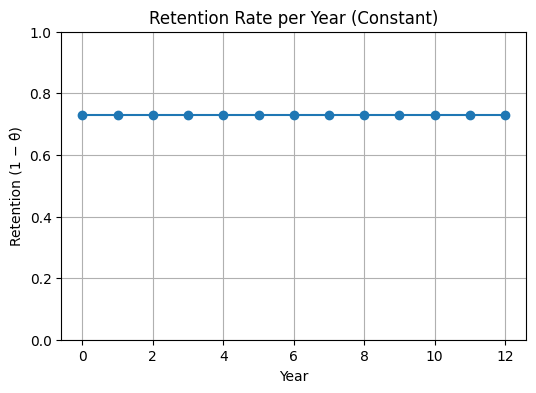

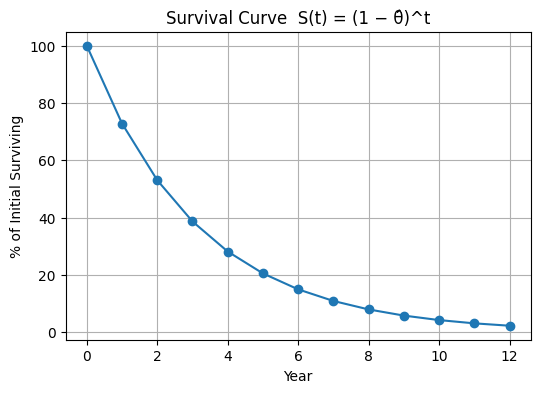

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(6,4))
plt.plot(df["Year"], np.full(len(df), retention_hat, dtype=float), marker="o")
plt.ylim(0, 1)
plt.title("Retention Rate per Year (Constant)")
plt.xlabel("Year")
plt.ylabel("Retention (1 − θ̂)")
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.plot(df["Year"], 100 * df["S(t)"], marker="o")
plt.title("Survival Curve  S(t) = (1 − θ̂)^t")
plt.xlabel("Year")
plt.ylabel("% of Initial Surviving")
plt.grid(True)
plt.show()


Summary

In [ ]:

S5  = df.loc[df["Year"].eq(5),  "S(t)"].iloc[0]
S12 = df.loc[df["Year"].eq(12), "S(t)"].iloc[0]

summary = {
    "theta_hat (churn)": round(theta_hat, 9),
    "retention_hat": round(retention_hat, 9),
    "Excel_style_LL (Years 0–4)": round(ll_excel, 6),
    "S(5)": round(S5, 3),
    "S(12)": round(S12, 3),
    "in_sample_mape_% (Years 1–4)": round(in_mape, 1),
    "out_sample_mape_% (Years 5–12)": round(out_mape, 1)
}
summary


{'theta_hat (churn)': np.float64(0.271664651),
 'retention_hat': np.float64(0.728335349),
 'Excel_style_LL (Years 0–4)': -1451.155556,
 'S(5)': np.float64(0.205),
 'S(12)': np.float64(0.022),
 'in_sample_mape_% (Years 1–4)': np.float64(10.9),
 'out_sample_mape_% (Years 5–12)': np.float64(64.0)}